In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings


### Import the CSV File into DataFrame

In [8]:
df = pd.read_csv('data//stud.csv')

In [12]:
#Top 5 records 
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [13]:
#Last 5 records 
df.tail()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


### Preparing X and Y variables

In [20]:
X =  df.drop(['math_score'],axis = 1)
y = df['math_score']

In [17]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [19]:
print("Categories in Gender variable: ", end = " ")
print(df['gender'].unique())
print("Categories in race_ethnicity variable: ", end = " ")
print(df['race_ethnicity'].unique())
print("Categories in parental_level_of_education variable: ", end = " ")
print(df['parental_level_of_education'].unique())
print("Categories in lunch variable: ", end = " ")
print(df['lunch'].unique())
print("Categories in test_preparation_course variable: ", end = " ")
print(df['test_preparation_course'].unique())

Categories in Gender variable:  <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in race_ethnicity variable:  <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in parental_level_of_education variable:  <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in lunch variable:  <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in test_preparation_course variable:  <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [22]:
#Create column Transformer with 3 types 
num_features =  X.select_dtypes(exclude='object').columns
cat_features = X.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
[
    ("OneHotEncoder",oh_transformer,cat_features),
    ("StandardScaler",numeric_transformer,num_features)
])

C:\Users\amitp\AppData\Local\Temp\ipykernel_29204\2058588703.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include='object').columns


In [23]:
X=preprocessor.fit_transform(X)

### Separate Dataset into Train and Test


In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((800, 19), (200, 19))

### Create an Evaluate Function to give all metrics after model Training

In [28]:
def evaluate_model(true,predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mean_squared_error(true,predicted))
    r2_square = r2_score(true,predicted)
    return mae,rmse,r2_square

In [40]:
models = {
    "LinearRegression":LinearRegression(),
    "Lasso":Lasso(),
    "Ridge":Ridge(),
    "K-Neighbors Regressor":KNeighborsRegressor(),
    "Random Forest Regressor" : RandomForestRegressor(),
    "XGBRegressor" : XGBRegressor(),
    "CatBoosting Regressor" : CatBoostRegressor(verbose=False),
    "AdaBoost Regressor" : AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    #Make Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    #Evaluate Train and Test Dataset
    model_train_mae,model_train_rmse,model_train_r2 = evaluate_model(y_train,y_train_pred)
    model_test_mae,model_test_rmse,model_test_r2 = evaluate_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model Performance for Training Set")
    print("Mean Absolute Error:",model_train_mae),
    print("Root mean Squared Error : ",model_train_rmse),
    print("R2 Score :",model_train_r2)


    print('-------------------------------------------------')
    print("Model Performance for Test Set")
    print("Mean Absolute Error:",model_test_mae),
    print("Root mean Squared Error : ",model_test_rmse),
    print("R2 Score :",model_test_r2)
    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')

LinearRegression
Model Performance for Training Set
Mean Absolute Error: 4.266711846071957
Root mean Squared Error :  5.323050852720513
R2 Score : 0.8743172040139593
-------------------------------------------------
Model Performance for Test Set
Mean Absolute Error: 4.21476314247485
Root mean Squared Error :  5.393993869732843
R2 Score : 0.8804332983749565


Lasso
Model Performance for Training Set
Mean Absolute Error: 5.206302661246528
Root mean Squared Error :  6.593815587795567
R2 Score : 0.8071462015863456
-------------------------------------------------
Model Performance for Test Set
Mean Absolute Error: 5.157881810347764
Root mean Squared Error :  6.519694535667421
R2 Score : 0.8253197323627852


Ridge
Model Performance for Training Set
Mean Absolute Error: 4.264987823725978
Root mean Squared Error :  5.323324922741656
R2 Score : 0.8743042615212908
-------------------------------------------------
Model Performance for Test Set
Mean Absolute Error: 4.211100688014261
Root mean S

### Result

In [41]:
pd.DataFrame({
    "Model Name": model_list,
    "R2_Score": r2_list
}).sort_values(by="R2_Score", ascending=False)

,Model Name,R2_Score
2,Ridge,0.880593
0,LinearRegression,0.880433
7,AdaBoost Regressor,0.854693
4,Random Forest Regressor,0.852408
6,CatBoosting Regressor,0.851632
5,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighbors Regressor,0.783813


### Linear Regression

In [42]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train,y_train)
y_pred= lin_model.predict(X_test)
score = r2_score (y_test,y_pred)*100
print("Accuracy of the model is %.2f"%score)

Accuracy of the model is 88.04


###

Text(0, 0.5, 'predicted')

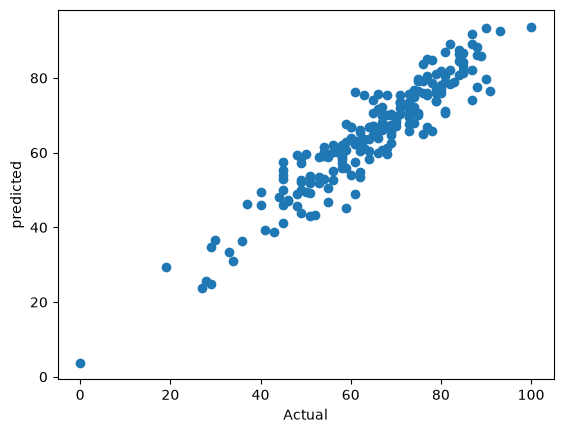

In [43]:
### Plotting y_pred and y_Test
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('predicted')

### 

<Axes: xlabel='math_score'>

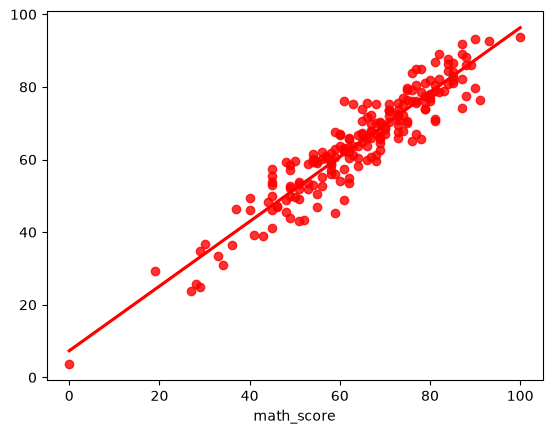

In [44]:
sns.regplot(x = y_test,y=y_pred, ci=None, color ='red')

###

### Difference between Actual and predicted value

In [46]:
pred_df = pd.DataFrame({'Actual Value': y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
